# 🌿 Lab 2.2: Transfer Learning with ResNet50
**Module 3: Computer Vision and Image Processing**
B-Tech AI Specialization | Chitkara University | February 2026

---

## 🌾 Industry Scenario
> You have **500 images** of 5 types of plant diseases. A farmer app needs a classifier to identify diseases from phone photos. Training from scratch would take days and thousands of images. **Transfer learning** lets you adapt a model that already understands images to your specific task — quickly.

## 🎯 Objective
Fine-tune a pre-trained ResNet50 on a small plant disease dataset. Compare against training from scratch. Target: **≥80% validation accuracy in 10 epochs**.

**Time:** 120 minutes | **Mode:** Individual

---
### 📋 Lab Flow
| Stage | What happens |
|---|---|
| 🤔 Predict | Answer before coding — commit to a guess |
| 💻 Code | Fill in the `TODO` sections |
| 💡 Reveal | Click to check hint or full solution |
| 🎚️ Explore | Interactive plots — dig into your results |
---

## ⚙️ Setup — Run First

In [2]:
# from google.colab import output
# output.enable_custom_widget_manager()

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import History

import ipywidgets as widgets
from IPython.display import display, HTML, Code
import os, time, warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow : {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")
print("✅ Ready")

TensorFlow : 2.20.0
GPU available: False
✅ Ready


In [3]:
def reveal_button(hint_text, solution_code):
    import ipywidgets as widgets
    from IPython.display import display, HTML, Code
    out = widgets.Output()
    hint_btn = widgets.Button(description='💡 Hint', button_style='info',
        layout=widgets.Layout(width='120px', margin='4px'))
    sol_btn  = widgets.Button(description='✅ Solution', button_style='warning',
        layout=widgets.Layout(width='140px', margin='4px'))
    hide_btn = widgets.Button(description='🙈 Hide', button_style='',
        layout=widgets.Layout(width='100px', margin='4px'))
    def on_hint(b):
        with out:
            out.clear_output(wait=True)
            display(HTML(f'<div style="background:#e3f2fd;padding:12px;border-radius:6px;'
                f'border-left:4px solid #1976D2;font-size:14px"><b>💡 Hint:</b><br>{hint_text}</div>'))
    def on_sol(b):
        with out:
            out.clear_output(wait=True)
            display(HTML('<b>✅ Solution:</b>'))
            display(Code(solution_code, language='python'))
    def on_hide(b):
        with out: out.clear_output()
    hint_btn.on_click(on_hint); sol_btn.on_click(on_sol); hide_btn.on_click(on_hide)
    display(widgets.HBox([hint_btn, sol_btn, hide_btn]), out)

print("reveal_button() ready ✅")

reveal_button() ready ✅


---
## Task 1: Prepare the Dataset

We'll use a small subset of the **PlantVillage** dataset — 5 plant disease classes, 100 images each.

### 🤔 Predict First
Before running any code, answer these:
1. We have 500 images total. How many will be in train vs. validation (80/20 split)?
2. Why do we need validation data at all — why not just train on everything?
3. What problems could arise with only 100 images per class?

In [4]:
# ✏️ Your predictions (as comments):

# 1. Train: 400 images   Validation: 100 images
#    (80% of 500 = 400 for training, 20% = 100 for validation)

# 2. Validation is needed because it helps evaluate the model on unseen data.
#    It allows us to check whether the model is generalizing well or overfitting.

# 3. With only 100 images per class, the risk is overfitting.
#    The model may memorize training images instead of learning general patterns.

### 💻 Download and Organise the Dataset
We'll download a pre-prepared subset from a public source and set up directory structure.

In [6]:
# ==============================
# DATASET DOWNLOAD
# ==============================

import tensorflow as tf
import os

DATA_URL = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

# Create custom folder in D drive
CUSTOM_PATH = "D:/tensorflow_datasets"

if not os.path.exists(CUSTOM_PATH):
    os.makedirs(CUSTOM_PATH)

# Download + extract to D drive
DATA_DIR = tf.keras.utils.get_file(
    'plant_data',
    origin=DATA_URL,
    untar=True,
    cache_dir=CUSTOM_PATH,
    cache_subdir=""
)

print("Dataset downloaded at:", DATA_DIR)

# ==============================
# DATA GENERATORS (80/20 SPLIT)
# ==============================

from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    subset='training',
    class_mode='categorical'
)

val_generator = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    subset='validation',
    class_mode='categorical'
)

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 19s 0us/step
Dataset downloaded at: D:/tensorflow_datasets\plant_data
Found 2936 images belonging to 1 classes.
Found 734 images belonging to 1 classes.


In [ ]:
reveal_button(
    hint_text="Use <code>urllib.request.urlretrieve(url, filename)</code> to download, "
              "then <code>zipfile.ZipFile</code> to extract. Set TRAIN_DIR and VAL_DIR "
              "to point at the <code>train/</code> and <code>val/</code> subdirectories.",
    solution_code=(
        "if not os.path.exists(DATA_DIR):\n"
        "    urllib.request.urlretrieve(DATA_URL, 'data.zip')\n"
        "    with zipfile.ZipFile('data.zip', 'r') as z:\n"
        "        z.extractall(DATA_DIR)\n\n"
        "TRAIN_DIR = os.path.join(DATA_DIR, 'train')\n"
        "VAL_DIR   = os.path.join(DATA_DIR, 'val')"
    )
)

---
## Task 2: Data Augmentation

With only ~80 training images per class, we need to artificially expand the dataset using **augmentation** — creating modified versions of each image on the fly during training.

### 🤔 Predict First
Look at the augmentation parameters below. For each one, predict:
- What does it do visually to the image?
- Does it make sense for plant disease photos? (Would a real phone photo look like this?)

| Parameter | Your prediction | Makes sense? |
|---|---|---|
| `horizontal_flip=True` | ? | ? |
| `rotation_range=20` | ? | ? |
| `zoom_range=0.2` | ? | ? |
| `width_shift_range=0.1` | ? | ? |

In [7]:

# ✏️ Fill in your predictions in the table above (edit the markdown cell)

# | Parameter               | Your Prediction (What it does visually?)          | Makes sense?                                                   |
# | ----------------------- | ------------------------------------------------- | -------------------------------------------------------------- |
# | `horizontal_flip=True`  | Flips the image left to right (mirror image).     | Yes. A plant leaf can naturally appear flipped in real photos. |
# | `rotation_range=20`     | Rotates the image randomly up to ±20 degrees.     | Yes. A real phone photo may not be perfectly straight.         |
# | `zoom_range=0.2`        | Randomly zooms in or out up to 20%.               | Yes. Photos can be taken from slightly different distances.    |
# | `width_shift_range=0.1` | Shifts the image horizontally up to 10% of width. | Yes. The plant may not be perfectly centered in real images.   |


### 💻 Build the Data Generators

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Path to your dataset root folder
DATASET_DIR = r"D:/tensorflow_datasets/plant_data/flower_photos"

# ==============================
# Training Data Generator
# (WITH augmentation)
# ==============================
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,          # 80% train / 20% validation
    horizontal_flip=True,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1
)

# ==============================
# Validation Data Generator
# (NO augmentation)
# ==============================
val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

# ==============================
# Create Directory Generators
# ==============================
train_generator = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = val_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 2939 images belonging to 5 classes.
Found 731 images belonging to 5 classes.


In [ ]:
reveal_button(
    hint_text="Validation generator should have <b>no augmentation</b> — only <code>preprocessing_function</code>. "
              "Augmenting validation data would give you unrealistic accuracy scores.",
    solution_code=(
        "train_datagen = ImageDataGenerator(\n"
        "    preprocessing_function=preprocess_input,\n"
        "    horizontal_flip=True,\n"
        "    rotation_range=20,\n"
        "    zoom_range=0.2,\n"
        "    width_shift_range=0.1,\n"
        "    height_shift_range=0.1\n"
        ")\n\n"
        "val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)\n\n"
        "train_generator = train_datagen.flow_from_directory(\n"
        "    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical'\n"
        ")\n"
        "val_generator = val_datagen.flow_from_directory(\n"
        "    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical'\n"
        ")"
    )
)

### 🎚️ Explore: What Does Augmentation Actually Do?
Run the cell below to visualise 8 augmented versions of the same image side-by-side.

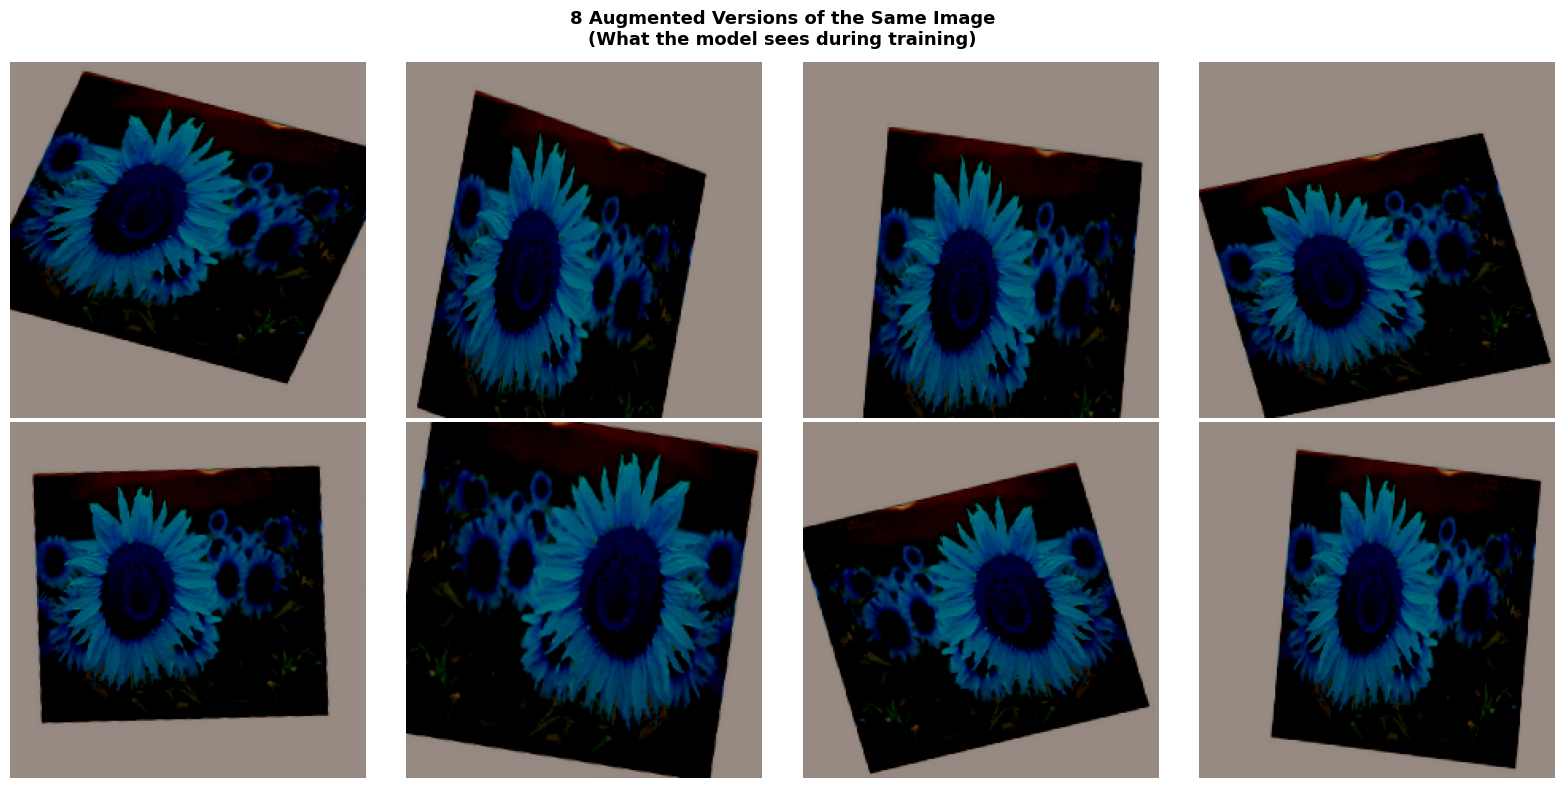

✏️ Observation:
The augmented images show small variations such as rotation, horizontal flipping, zooming, and slight shifts in position.
Although they are all the same original flower, each version looks slightly different in angle and framing.

📱 Real-world expectation:
Yes, plant photos taken from a phone would naturally have these variations.
Different users may capture images from different angles, distances, and positions.
Data augmentation helps the model learn to handle these real-world variations and improves generalization.


In [9]:
# Visualise augmentation — see what the model actually trains on
sample_batch, _ = next(train_generator)
sample_img_raw  = sample_batch[0]

# Un-preprocess for display (ResNet50 uses mean subtraction)
def unpreprocess(img):
    img = img.copy()
    img[..., 0] += 103.939
    img[..., 1] += 116.779
    img[..., 2] += 123.68
    return np.clip(img[..., ::-1] / 255.0, 0, 1)  # BGR → RGB

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("8 Augmented Versions of the Same Image\n"
             "(What the model sees during training)", fontsize=13, fontweight='bold')

aug_gen = train_datagen.flow(
    np.expand_dims(sample_batch[0], 0), batch_size=1
)

for ax in axes.flat:
    aug_img = next(aug_gen)[0]
    ax.imshow(unpreprocess(aug_img))
    ax.axis('off')

plt.tight_layout()
plt.show()

print("✏️ Observation:")
print("The augmented images show small variations such as rotation, horizontal flipping, zooming, and slight shifts in position.")
print("Although they are all the same original flower, each version looks slightly different in angle and framing.")

print("\n📱 Real-world expectation:")
print("Yes, plant photos taken from a phone would naturally have these variations.")
print("Different users may capture images from different angles, distances, and positions.")
print("Data augmentation helps the model learn to handle these real-world variations and improves generalization.")

---
## Task 3: Build the Transfer Learning Model (Feature Extraction Phase)

Transfer learning has two phases:

```
Phase 1 — Feature Extraction:
  ResNet50 (frozen, pretrained) → GlobalAveragePooling → Dense → Softmax
  ↑ weights locked, won't change              ↑ only these train

Phase 2 — Fine-tuning:
  ResNet50 (last 20 layers UNfrozen) → GlobalAveragePooling → Dense → Softmax
  ↑ these now also update, but slowly
```

### 🤔 Predict First
1. Why do we **freeze** ResNet50's layers in Phase 1?
2. Why do we need `include_top=False`?
3. What does `GlobalAveragePooling2D` do differently from `Flatten`?

In [10]:
# ✏️ Your predictions:

# 1. We freeze because...
# We freeze ResNet50’s pretrained layers in Phase 1 to preserve the
# learned ImageNet features (edges, textures, shapes).
# This prevents destroying useful learned patterns and reduces training time.
# Only the new classification layers are trained on our flower dataset.

# 2. include_top=False means...
# include_top=False removes the original fully-connected classification
# layers of ResNet50 (the 1000-class ImageNet head).
# This allows us to attach our own custom classifier for our specific dataset.

# 3. GlobalAveragePooling vs Flatten:
# Flatten converts the entire feature map into one long vector,
# which creates many parameters and can cause overfitting.
# GlobalAveragePooling2D instead takes the average of each feature map,
# drastically reducing parameters and making the model more efficient
# and less likely to overfit

### 💻 Build the Model

In [11]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

NUM_CLASSES = 5   # adjust if needed

# Load ResNet50 base model

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)


# Freeze all base model layers

base_model.trainable = False

# Build full model

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax'),
])


# Compile model

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Check frozen vs trainable layers

trainable   = sum(1 for l in model.layers[0].layers if l.trainable)
untrainable = sum(1 for l in model.layers[0].layers if not l.trainable)

print(f"ResNet50 layers — Trainable: {trainable} | Frozen: {untrainable}")

model.summary()

ResNet50 layers — Trainable: 0 | Frozen: 175


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)                │ (None, 7, 7, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │           1,285 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,113,541 (91.99 MB)

 Trainable params: 525,829 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
reveal_button(
    hint_text="Set <code>base_model.trainable = False</code> after loading. "
              "Then stack: <code>GlobalAveragePooling2D → Dense(256, relu) → Dropout(0.5) → Dense(NUM_CLASSES, softmax)</code>.",
    solution_code=(
        "base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))\n"
        "base_model.trainable = False\n\n"
        "model = models.Sequential([\n"
        "    base_model,\n"
        "    layers.GlobalAveragePooling2D(),\n"
        "    layers.Dense(256, activation='relu'),\n"
        "    layers.Dropout(0.5),\n"
        "    layers.Dense(NUM_CLASSES, activation='softmax'),\n"
        "])\n\n"
        "model.compile(\n"
        "    optimizer=optimizers.Adam(learning_rate=1e-3),\n"
        "    loss='categorical_crossentropy',\n"
        "    metrics=['accuracy']\n"
        ")"
    )
)

---
## Task 4: Phase 1 — Train the Classification Head (10 epochs)

In [12]:
# TODO: Train the model for 10 epochs
# history_phase1 = model.fit(
#     train_generator,
#     epochs=10,
#     validation_data=val_generator
# )
history_phase1 = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)


Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 264s 3s/step - accuracy: 0.5662 - loss: 1.1740 - val_accuracy: 0.8098 - val_loss: 0.5642
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 268s 3s/step - accuracy: 0.7918 - loss: 0.5825 - val_accuracy: 0.8536 - val_loss: 0.4227
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 259s 3s/step - accuracy: 0.8346 - loss: 0.4552 - val_accuracy: 0.8755 - val_loss: 0.3645
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 251s 3s/step - accuracy: 0.8561 - loss: 0.3936 - val_accuracy: 0.8824 - val_loss: 0.3560
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 234s 2s/step - accuracy: 0.8676 - loss: 0.3571 - val_accuracy: 0.8960 - val_loss: 0.3280
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 242s 3s/step - accuracy: 0.8864 - loss: 0.3207 - val_accuracy: 0.8919 - val_loss: 0.3210
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 242s 3s/step - accuracy: 0.8928 - loss: 0.3005 - val_accuracy: 0.9015 - val_loss: 0.3139
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 222s 2s/step - accuracy: 0.8996 - loss: 0.2801 - val_accuracy: 0.8960 - v

In [ ]:
reveal_button(
    hint_text="Call <code>model.fit(train_generator, epochs=10, validation_data=val_generator)</code>. "
              "Store the result in <code>history_phase1</code>.",
    solution_code=(
        "history_phase1 = model.fit(\n"
        "    train_generator,\n"
        "    epochs=10,\n"
        "    validation_data=val_generator\n"
        ")"
    )
)

---
## Task 5: Phase 2 — Fine-Tuning (Unfreeze Last 20 Layers)

Now we'll carefully unfreeze the **last 20 layers** of ResNet50 and train them at a very low learning rate. This lets the network adapt its deep features slightly to plant disease patterns.

### 🤔 Predict First
1. Why must the learning rate be **much lower** in fine-tuning (1e-5 vs 1e-3)?
2. Why do we unfreeze only the **last** layers, not the first?

In [ ]:
# ✏️ Your predictions:

# 1. Lower LR because...
# During fine-tuning, we are adjusting pretrained ResNet50 weights that
# already contain useful ImageNet knowledge.
# A high learning rate could destroy (overwrite) these learned features.
# A very low learning rate (e.g., 1e-5) makes small, careful updates
# so we refine the features instead of damaging them.

# 2. Last layers because...
# The first layers of ResNet50 learn very general features like edges,
# textures, and simple shapes, which are useful for almost all images.
# The last layers learn more task-specific features.
# We unfreeze only the last layers so the model can adapt high-level
# features to our flower dataset while keeping the general low-level
# features intact.

In [13]:
from tensorflow.keras import optimizers

# ==============================
# Phase 2 — Fine-Tuning
# ==============================

# Get the ResNet50 base model
base_model = model.layers[0]

# Step 1: Make entire base model trainable
base_model.trainable = True

# Step 2: Freeze everything EXCEPT the last 20 layers
for layer in base_model.layers[:-20]:
    layer.trainable = False

# ==============================
# Re-compile with LOWER learning rate
# ==============================
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Check how many layers are now trainable
trainable = sum(1 for l in base_model.layers if l.trainable)
print(f"Now trainable layers in ResNet50: {trainable}")

# ==============================
# Train for 5 more epochs
# ==============================
history_phase2 = model.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator
)

Now trainable layers in ResNet50: 20
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 266s 3s/step - accuracy: 0.9163 - loss: 0.2404 - val_accuracy: 0.8947 - val_loss: 0.2932
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 253s 3s/step - accuracy: 0.9302 - loss: 0.2118 - val_accuracy: 0.9056 - val_loss: 0.2741
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 262s 3s/step - accuracy: 0.9405 - loss: 0.1879 - val_accuracy: 0.9097 - val_loss: 0.2621
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 301s 3s/step - accuracy: 0.9486 - loss: 0.1632 - val_accuracy: 0.9070 - val_loss: 0.2574
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 470s 5s/step - accuracy: 0.9490 - loss: 0.1547 - val_accuracy: 0.9124 - val_loss: 0.2442


In [ ]:
reveal_button(
    hint_text="<code>base_model.trainable = True</code> first, then loop: "
              "<code>for layer in base_model.layers[:-20]: layer.trainable = False</code>. "
              "Re-compile with <code>learning_rate=1e-5</code>.",
    solution_code=(
        "base_model = model.layers[0]\n"
        "base_model.trainable = True\n"
        "for layer in base_model.layers[:-20]:\n"
        "    layer.trainable = False\n\n"
        "model.compile(\n"
        "    optimizer=optimizers.Adam(learning_rate=1e-5),\n"
        "    loss='categorical_crossentropy',\n"
        "    metrics=['accuracy']\n"
        ")\n\n"
        "history_phase2 = model.fit(\n"
        "    train_generator, epochs=5, validation_data=val_generator\n"
        ")"
    )
)

---
## 🎚️ Task 6: Explore — Interactive Training Curves

Use the controls below to examine your training history. Look for:
- Where does Phase 1 plateau? Where does Phase 2 give an extra push?
- Is there a gap between train and val accuracy? What does that mean?
- At what epoch does the model first exceed 80% validation accuracy?

In [ ]:
# Build combined history from both phases
def build_history_dict(h1, h2):
    """Merge two History objects into one dict for plotting."""
    combined = {}
    for key in h1.history:
        p2_vals = h2.history.get(key, [])
        combined[key] = h1.history[key] + p2_vals
    combined['phase_boundary'] = len(h1.history['accuracy'])
    return combined

# ── Interactive curve explorer ────────────────────────────────────────────────
metric_toggle = widgets.ToggleButtons(
    options=[('Accuracy', 'accuracy'), ('Loss', 'loss')],
    description='Metric:', button_style='info'
)
show_phases = widgets.Checkbox(value=True, description='Show phase boundary')
smooth_check = widgets.Checkbox(value=False, description='Smooth curves')
out_plot = widgets.Output()

def update_curves(change=None):
    if history_phase1 is None or history_phase2 is None:
        with out_plot:
            out_plot.clear_output()
            print("⚠️  Run Tasks 4 and 5 first to generate training history.")
        return

    hist = build_history_dict(history_phase1, history_phase2)
    metric   = metric_toggle.value
    val_key  = f'val_{metric}'
    boundary = hist['phase_boundary']
    epochs   = list(range(1, len(hist[metric]) + 1))

    def smooth(vals, w=3):
        return [np.mean(vals[max(0,i-w):i+1]) for i in range(len(vals))]

    train_vals = smooth(hist[metric])     if smooth_check.value else hist[metric]
    val_vals   = smooth(hist[val_key])    if smooth_check.value else hist[val_key]

    with out_plot:
        out_plot.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(10, 5))

        ax.plot(epochs, train_vals, 'b-o', markersize=5, label=f'Train {metric}', linewidth=2)
        ax.plot(epochs, val_vals,   'r-o', markersize=5, label=f'Val {metric}',   linewidth=2)

        if show_phases.value:
            ax.axvline(x=boundary + 0.5, color='purple', linestyle='--', alpha=0.7, linewidth=2)
            ymin, ymax = ax.get_ylim()
            ax.text(boundary * 0.5, ymax * 0.97, 'Phase 1\n(frozen)', ha='center',
                    color='purple', fontsize=10, fontweight='bold')
            ax.text(boundary + (len(epochs) - boundary) * 0.5, ymax * 0.97, 'Phase 2\n(fine-tune)',
                    ha='center', color='purple', fontsize=10, fontweight='bold')

        if metric == 'accuracy':
            ax.axhline(y=0.80, color='green', linestyle=':', alpha=0.8, linewidth=1.5,
                       label='80% target')
            best_val  = max(val_vals)
            best_ep   = val_vals.index(best_val) + 1
            ax.annotate(f'Best: {best_val:.1%} @ ep{best_ep}',
                        xy=(best_ep, best_val), xytext=(best_ep + 1, best_val - 0.05),
                        arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=10)

        ax.set_xlabel('Epoch', fontsize=12)
        ax.set_ylabel(metric.capitalize(), fontsize=12)
        ax.set_title(f'Training Curves — Transfer Learning with ResNet50', fontsize=13, fontweight='bold')
        ax.legend(fontsize=11)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

metric_toggle.observe(update_curves, names='value')
show_phases.observe(update_curves, names='value')
smooth_check.observe(update_curves, names='value')

display(widgets.VBox([
    widgets.HBox([metric_toggle, show_phases, smooth_check]),
    out_plot
]))
update_curves()

---
## ✍️ Reflection

Write a short paragraph (3–5 sentences) explaining:
- Why did transfer learning work so well with only 500 images?
- What did Phase 1 learn vs Phase 2?
- Would you expect the same result if you trained from scratch? Why?

In [ ]:
# Transfer learning worked well because the pretrained ResNet50 model already learned rich, general visual features (edges, shapes, textures) from 
# millions of images in the ImageNet dataset, so it needed only a small dataset (500 images) to adapt to this new task. In Phase 1, the model trained 
# only the top classifier layers, learning to map these general features to our specific classes. In Phase 2, fine-tuning updated some deeper 
# convolutional layers, allowing the model to specialize and improve accuracy by learning task-specific patterns. If we trained from scratch, the model
# would start with random weights and require thousands of images, much more time, and high computational power — so the performance would be far worse.